# Timed Planetary Rover Experimental Study

## Research question

**How do onboard memory capacity, the number of scientific datasets, and time-dependent data degradation affect the feasibility, efficiency, and computational difficulty of planetary-rover plans generated with PDDL+?**

This notebook analyses the five-seed timed-rover experiment.

### Experimental factors

- Dataset count: 3, 5, and 7
- Memory level: low, medium, and high
- Corruption level: low, medium, and high
- Seeds: 0–4
- Standard planner budget: 60 seconds
- Extended feasibility check: 180 seconds, applied only to the original timeouts

### Main response variables

- Final planning status
- Planner wall-clock runtime
- Temporal plan makespan
- Explicit action count
- Movement count
- Estimated travel time
- Stationary time


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import chi2_contingency, friedmanchisquare, kruskal

warnings.filterwarnings("ignore", category=FutureWarning)

CORRUPTION_ORDER = ["low", "medium", "high"]
MEMORY_ORDER = ["low", "medium", "high"]
DATASET_ORDER = [3, 5, 7]
STATUS_ORDER = ["solved", "unsolvable", "timeout"]


def find_project_root(start: Path) -> Path:
    """Find the repository root from either the root or notebooks folder."""
    expected = Path(
        "experiments/results/timed_pilot_5_seeds_extended.csv"
    )

    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / expected).is_file():
            return candidate

    raise FileNotFoundError(
        "Could not find the repository root. "
        "Confirm that timed_pilot_5_seeds_extended.csv exists."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
RESULTS_PATH = (
    PROJECT_ROOT
    / "experiments/results/timed_pilot_5_seeds_extended.csv"
)
PLOT_DIR = PROJECT_ROOT / "experiments/plots"
TABLE_DIR = PROJECT_ROOT / "experiments/results/tables"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", RESULTS_PATH)
print("Plot directory:", PLOT_DIR)
print("Table directory:", TABLE_DIR)


Project root: /mnt/c/Users/Endri/Desktop/planetary-rover-experimental-study
Dataset: /mnt/c/Users/Endri/Desktop/planetary-rover-experimental-study/experiments/results/timed_pilot_5_seeds_extended.csv
Plot directory: /mnt/c/Users/Endri/Desktop/planetary-rover-experimental-study/experiments/plots
Table directory: /mnt/c/Users/Endri/Desktop/planetary-rover-experimental-study/experiments/results/tables


## 1. Load and validate the experiment data

The extended CSV preserves the original 60-second outcome and adds the result of the selective 180-second reruns. Runtime comparisons must use the original 60-second measurements so every instance has the same computational budget.


In [2]:
df = pd.read_csv(RESULTS_PATH)

numeric_columns = [
    "seed",
    "dataset_count",
    "memory_ratio",
    "memory_capacity",
    "total_dataset_size",
    "memory_utilization_ratio",
    "travel_time_per_edge",
    "safe_dataset_count",
    "unsafe_dataset_count",
    "timeout_seconds",
    "wall_runtime_seconds",
    "reported_plan_length",
    "reported_elapsed_time",
    "plan_makespan",
    "estimated_travel_time",
    "stationary_time",
    "action_count",
    "move_actions",
    "collect_actions",
    "offload_actions",
    "waiting_periods",
    "total_waiting_time",
    "runtime_60s_seconds",
    "extended_runtime_seconds",
    "classification_limit_seconds",
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

df["memory_level"] = pd.Categorical(
    df["memory_level"],
    categories=MEMORY_ORDER,
    ordered=True,
)
df["corruption_level"] = pd.Categorical(
    df["corruption_level"],
    categories=CORRUPTION_ORDER,
    ordered=True,
)

df["solved_final"] = df["final_status"].eq("solved")
df["contains_unsafe_dataset"] = df["unsafe_dataset_count"].gt(0)

print("Shape:", df.shape)
display(df.head())


Shape: (135, 48)


,instance_id,model,seed,dataset_count,memory_level,memory_ratio,memory_capacity,total_dataset_size,memory_utilization_ratio,travel_time_per_edge,...,error_message,status_60s,runtime_60s_seconds,extended_status,extended_runtime_seconds,final_status,classification_limit_seconds,resolved_by_extended_run,solved_final,contains_unsafe_dataset
0,rover-timed-n3-mem-low-corr-low-seed-0,timed,0,3,low,0.35,5,12,2.400000,2.0,...,NaN,solved,0.494360,NaN,NaN,solved,60,False,True,False
1,rover-timed-n3-mem-low-corr-low-seed-1,timed,1,3,low,0.35,6,11,1.833333,2.0,...,NaN,solved,0.497946,NaN,NaN,solved,60,False,True,False
2,rover-timed-n3-mem-low-corr-low-seed-2,timed,2,3,low,0.35,3,6,2.000000,2.0,...,NaN,solved,0.538338,NaN,NaN,solved,60,False,True,False
3,rover-timed-n3-mem-low-corr-low-seed-3,timed,3,3,low,0.35,6,15,2.500000,2.0,...,NaN,solved,0.537136,NaN,NaN,solved,60,False,True,False
4,rover-timed-n3-mem-low-corr-low-seed-4,timed,4,3,low,0.35,4,9,2.250000,2.0,...,NaN,solved,0.509748,NaN,NaN,solved,60,False,True,False


In [3]:
assert len(df) == 135, f"Expected 135 rows, found {len(df)}"
assert df["instance_id"].is_unique, "Instance IDs are not unique."
assert set(df["dataset_count"].dropna().astype(int)) == {3, 5, 7}
assert set(df["seed"].dropna().astype(int)) == {0, 1, 2, 3, 4}
assert set(df["final_status"].dropna()) <= set(STATUS_ORDER)
assert df["model"].eq("timed").all()

status_60s = (
    df["status_60s"]
    .value_counts()
    .reindex(STATUS_ORDER, fill_value=0)
)
status_extended = (
    df["final_status"]
    .value_counts()
    .reindex(STATUS_ORDER, fill_value=0)
)

print("60-second status counts:")
display(status_60s.to_frame("count"))

print("Extended status counts:")
display(status_extended.to_frame("count"))

assert status_60s.to_dict() == {
    "solved": 66,
    "unsolvable": 62,
    "timeout": 7,
}
assert status_extended.to_dict() == {
    "solved": 66,
    "unsolvable": 67,
    "timeout": 2,
}

print("All validation checks passed.")


60-second status counts:


,count
status_60s,
solved,66
unsolvable,62
timeout,7


Extended status counts:


,count
final_status,
solved,66
unsolvable,67
timeout,2


All validation checks passed.


## 2. Status counts and feasibility

Timeouts are kept separate from unsolvable cases. A timeout means the planner did not finish within the computational budget; it does not prove that the planning problem has no solution.


,60-second budget,Extended classification
solved,66,66
unsolvable,62,67
timeout,7,2


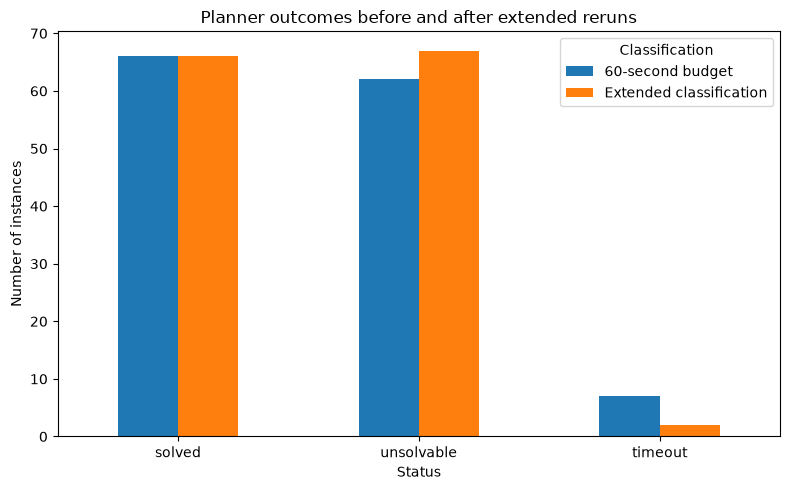

In [4]:
status_table = pd.DataFrame(
    {
        "60-second budget": status_60s,
        "Extended classification": status_extended,
    }
)

display(status_table)

ax = status_table.plot(kind="bar", figsize=(8, 5))
ax.set_title("Planner outcomes before and after extended reruns")
ax.set_xlabel("Status")
ax.set_ylabel("Number of instances")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Classification")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "status_counts_60s_vs_extended.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [5]:
def summarize_status(frame: pd.DataFrame, group_columns):
    """Summarize solved, unsolvable, and timeout outcomes by factors."""
    if isinstance(group_columns, str):
        group_columns = [group_columns]

    records = []

    for keys, group in frame.groupby(
        group_columns,
        observed=True,
        sort=False,
    ):
        if not isinstance(keys, tuple):
            keys = (keys,)

        record = dict(zip(group_columns, keys))
        counts = group["final_status"].value_counts()
        classified = group["final_status"].isin(
            ["solved", "unsolvable"]
        )
        classified_count = int(classified.sum())
        solved_count = int(counts.get("solved", 0))

        record.update(
            {
                "instances": len(group),
                "solved": solved_count,
                "unsolvable": int(counts.get("unsolvable", 0)),
                "timeout": int(counts.get("timeout", 0)),
                "success_rate_all": solved_count / len(group),
                "success_rate_classified": (
                    solved_count / classified_count
                    if classified_count
                    else np.nan
                ),
            }
        )
        records.append(record)

    return pd.DataFrame(records)


success_by_corruption = summarize_status(df, "corruption_level")
success_by_memory = summarize_status(df, "memory_level")
success_by_dataset = summarize_status(df, "dataset_count")
success_interaction = summarize_status(
    df,
    ["dataset_count", "corruption_level"],
)

print("Success by corruption level")
display(success_by_corruption)

print("Success by memory level")
display(success_by_memory)

print("Success by dataset count")
display(success_by_dataset)


Success by corruption level


,corruption_level,instances,solved,unsolvable,timeout,success_rate_all,success_rate_classified
0,low,45,45,0,0,1.000000,1.000000
1,medium,45,21,22,2,0.466667,0.488372
2,high,45,0,45,0,0.000000,0.000000


Success by memory level


,memory_level,instances,solved,unsolvable,timeout,success_rate_all,success_rate_classified
0,low,45,22,23,0,0.488889,0.488889
1,medium,45,22,22,1,0.488889,0.500000
2,high,45,22,22,1,0.488889,0.500000


Success by dataset count


,dataset_count,instances,solved,unsolvable,timeout,success_rate_all,success_rate_classified
0,3,45,27,18,0,0.600000,0.600000
1,5,45,21,24,0,0.466667,0.466667
2,7,45,18,25,2,0.400000,0.418605


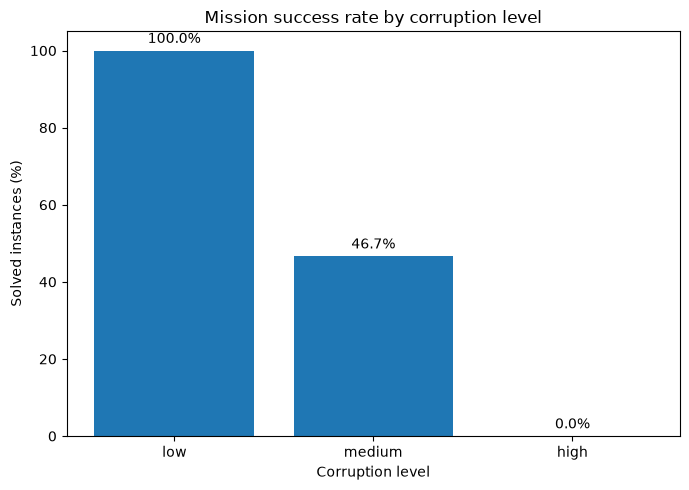

In [6]:
plot_data = success_by_corruption.copy()
plot_data["success_percent"] = (
    plot_data["success_rate_all"] * 100
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(
    plot_data["corruption_level"].astype(str),
    plot_data["success_percent"],
)
ax.set_title("Mission success rate by corruption level")
ax.set_xlabel("Corruption level")
ax.set_ylabel("Solved instances (%)")
ax.set_ylim(0, 105)

for index, value in enumerate(plot_data["success_percent"]):
    ax.text(index, value + 2, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.savefig(
    PLOT_DIR / "success_rate_by_corruption.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


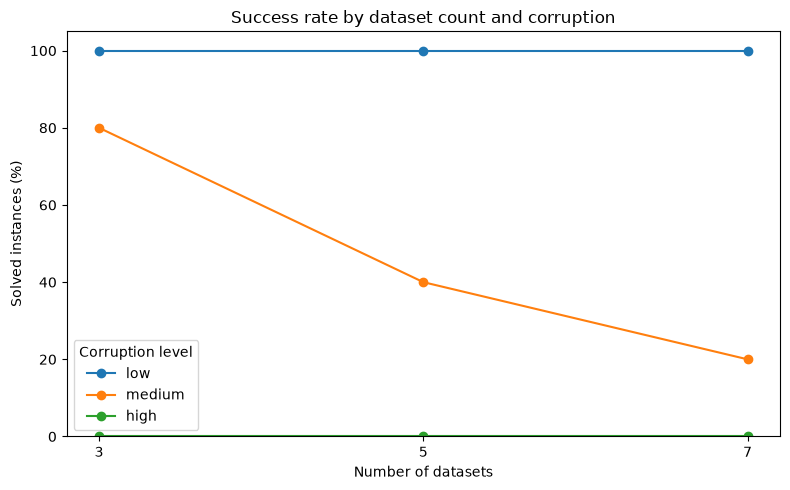

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

for corruption in CORRUPTION_ORDER:
    subset = success_interaction[
        success_interaction["corruption_level"].astype(str)
        == corruption
    ].sort_values("dataset_count")

    ax.plot(
        subset["dataset_count"],
        subset["success_rate_all"] * 100,
        marker="o",
        label=corruption,
    )

ax.set_title("Success rate by dataset count and corruption")
ax.set_xlabel("Number of datasets")
ax.set_ylabel("Solved instances (%)")
ax.set_xticks(DATASET_ORDER)
ax.set_ylim(0, 105)
ax.legend(title="Corruption level")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "success_rate_dataset_corruption.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 3. Planner runtime

Runtime analysis uses `runtime_60s_seconds`, including timeouts capped at approximately 60 seconds. Extended rerun times are excluded from this comparison because only the difficult timeout cases received the larger budget.


In [8]:
runtime_summary = (
    df.groupby("dataset_count", observed=True)
    .agg(
        instances=("instance_id", "count"),
        mean_runtime_60s=("runtime_60s_seconds", "mean"),
        median_runtime_60s=("runtime_60s_seconds", "median"),
        p90_runtime_60s=(
            "runtime_60s_seconds",
            lambda values: values.quantile(0.90),
        ),
        maximum_runtime_60s=("runtime_60s_seconds", "max"),
    )
    .reset_index()
)

display(runtime_summary)

runtime_by_status = (
    df.groupby("status_60s", observed=True)
    .agg(
        instances=("instance_id", "count"),
        mean_runtime_60s=("runtime_60s_seconds", "mean"),
        median_runtime_60s=("runtime_60s_seconds", "median"),
        maximum_runtime_60s=("runtime_60s_seconds", "max"),
    )
    .reindex(STATUS_ORDER)
)

display(runtime_by_status)


,dataset_count,instances,mean_runtime_60s,median_runtime_60s,p90_runtime_60s,maximum_runtime_60s
0,3,45,0.491675,0.490251,0.514333,0.542665
1,5,45,1.031805,0.745050,1.872974,3.274060
2,7,45,15.654302,5.918329,60.158454,60.188973


,instances,mean_runtime_60s,median_runtime_60s,maximum_runtime_60s
status_60s,,,,
solved,66,0.696154,0.627674,1.364920
unsolvable,62,4.933616,1.001372,57.187184
timeout,7,60.167121,60.164738,60.188973


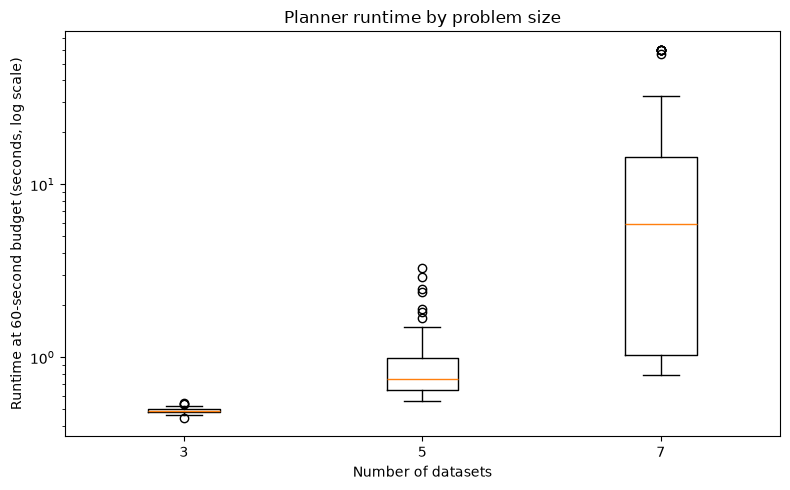

In [9]:
runtime_groups = [
    df.loc[
        df["dataset_count"].eq(dataset_count),
        "runtime_60s_seconds",
    ].dropna()
    for dataset_count in DATASET_ORDER
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    runtime_groups,
    tick_labels=[str(value) for value in DATASET_ORDER],
    showfliers=True,
)
ax.set_yscale("log")
ax.set_title("Planner runtime by problem size")
ax.set_xlabel("Number of datasets")
ax.set_ylabel("Runtime at 60-second budget (seconds, log scale)")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "runtime_by_dataset_count_log.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 4. Memory capacity and plan efficiency

To isolate the memory effect, this section uses only **low-corruption instances**. Every low-corruption instance was solved, so the efficiency comparison is not biased by excluding failed plans from some memory levels.


In [10]:
low_corruption_solved = df[
    df["corruption_level"].astype(str).eq("low")
    & df["final_status"].eq("solved")
].copy()

assert len(low_corruption_solved) == 45

memory_efficiency = (
    low_corruption_solved.groupby(
        "memory_level",
        observed=True,
    )
    .agg(
        instances=("instance_id", "count"),
        mean_makespan=("plan_makespan", "mean"),
        median_makespan=("plan_makespan", "median"),
        mean_actions=("action_count", "mean"),
        mean_moves=("move_actions", "mean"),
        mean_offloads=("offload_actions", "mean"),
        mean_travel_time=("estimated_travel_time", "mean"),
        mean_stationary_time=("stationary_time", "mean"),
    )
    .reset_index()
)

display(memory_efficiency)


,memory_level,instances,mean_makespan,median_makespan,mean_actions,mean_moves,mean_offloads,mean_travel_time,mean_stationary_time
0,low,15,60.266667,65.0,35.200000,25.200000,5.0,50.400000,9.866667
1,medium,15,49.266667,38.0,30.933333,20.933333,5.0,41.866667,7.400000
2,high,15,47.266667,39.0,30.000000,20.000000,5.0,40.000000,7.266667


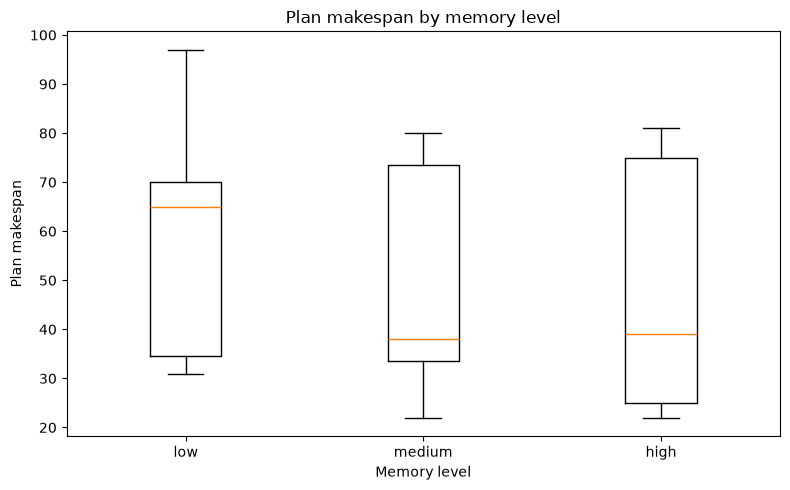

In [11]:
makespan_groups = [
    low_corruption_solved.loc[
        low_corruption_solved["memory_level"].astype(str).eq(level),
        "plan_makespan",
    ].dropna()
    for level in MEMORY_ORDER
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(makespan_groups, tick_labels=MEMORY_ORDER, showfliers=True)
ax.set_title("Plan makespan by memory level")
ax.set_xlabel("Memory level")
ax.set_ylabel("Plan makespan")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "makespan_by_memory_low_corruption.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


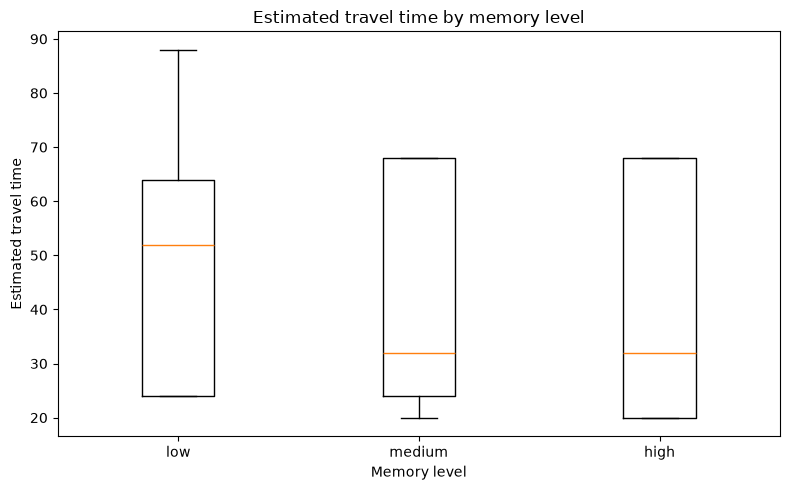

In [12]:
travel_groups = [
    low_corruption_solved.loc[
        low_corruption_solved["memory_level"].astype(str).eq(level),
        "estimated_travel_time",
    ].dropna()
    for level in MEMORY_ORDER
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(travel_groups, tick_labels=MEMORY_ORDER, showfliers=True)
ax.set_title("Estimated travel time by memory level")
ax.set_xlabel("Memory level")
ax.set_ylabel("Estimated travel time")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "travel_time_by_memory_low_corruption.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


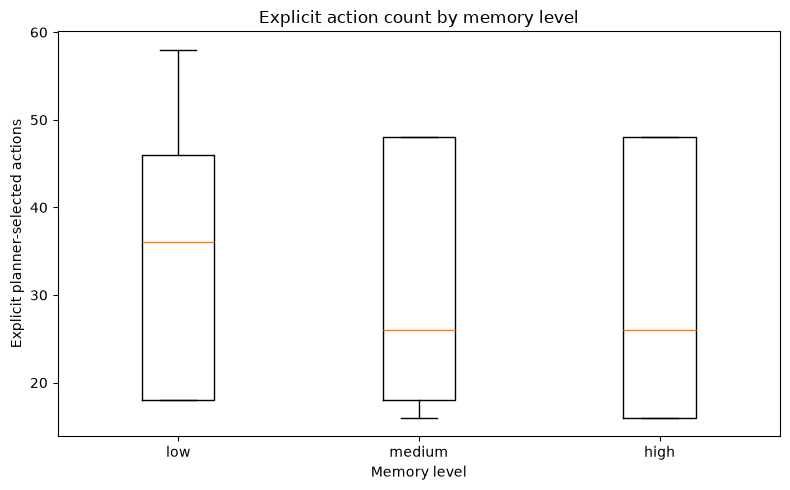

In [13]:
action_groups = [
    low_corruption_solved.loc[
        low_corruption_solved["memory_level"].astype(str).eq(level),
        "action_count",
    ].dropna()
    for level in MEMORY_ORDER
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(action_groups, tick_labels=MEMORY_ORDER, showfliers=True)
ax.set_title("Explicit action count by memory level")
ax.set_xlabel("Memory level")
ax.set_ylabel("Explicit planner-selected actions")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "action_count_by_memory_low_corruption.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 5. Exploratory statistical tests

These tests are exploratory because the experiment uses only five seeds and synthetic instances.

- A chi-square test examines the association between corruption level and final classified outcome.
- A Friedman test compares memory levels using matched missions under low corruption.
- A Kruskal–Wallis test examines planner runtime differences across dataset counts.

Timeouts are excluded only from the corruption-status chi-square table because they are not definitive feasibility outcomes.


In [14]:
statistical_results = []

classified = df[
    df["final_status"].isin(["solved", "unsolvable"])
].copy()

corruption_status_table = pd.crosstab(
    classified["corruption_level"],
    classified["final_status"],
).reindex(
    index=CORRUPTION_ORDER,
    columns=["solved", "unsolvable"],
    fill_value=0,
)

display(corruption_status_table)

chi2, p_value, degrees_freedom, expected = chi2_contingency(
    corruption_status_table
)

sample_size = corruption_status_table.to_numpy().sum()
minimum_dimension = min(
    corruption_status_table.shape[0] - 1,
    corruption_status_table.shape[1] - 1,
)
cramers_v = np.sqrt(
    chi2 / (sample_size * minimum_dimension)
)

statistical_results.append(
    {
        "test": "Chi-square: corruption level vs final status",
        "statistic": chi2,
        "p_value": p_value,
        "effect_size": cramers_v,
        "effect_size_name": "Cramer's V",
        "sample_size": sample_size,
    }
)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {degrees_freedom}")
print(f"p-value: {p_value:.6g}")
print(f"Cramer's V: {cramers_v:.4f}")
print("Expected frequencies:")
display(
    pd.DataFrame(
        expected,
        index=corruption_status_table.index,
        columns=corruption_status_table.columns,
    )
)


final_status,solved,unsolvable
corruption_level,,
low,45,0
medium,21,22
high,0,45


Chi-square statistic: 90.0208
Degrees of freedom: 2
p-value: 2.83287e-20
Cramer's V: 0.8227
Expected frequencies:


final_status,solved,unsolvable
corruption_level,,
low,22.330827,22.669173
medium,21.338346,21.661654
high,22.330827,22.669173


In [15]:
def run_friedman_memory_test(metric: str) -> dict:
    pivot = (
        low_corruption_solved.pivot_table(
            index=["dataset_count", "seed"],
            columns="memory_level",
            values=metric,
            aggfunc="first",
            observed=True,
        )
        .reindex(columns=MEMORY_ORDER)
        .dropna()
    )

    statistic, p_value = friedmanchisquare(
        pivot["low"],
        pivot["medium"],
        pivot["high"],
    )

    number_of_blocks = len(pivot)
    number_of_conditions = len(MEMORY_ORDER)
    kendalls_w = statistic / (
        number_of_blocks * (number_of_conditions - 1)
    )

    return {
        "test": f"Friedman: memory level effect on {metric}",
        "statistic": statistic,
        "p_value": p_value,
        "effect_size": kendalls_w,
        "effect_size_name": "Kendall's W",
        "sample_size": number_of_blocks,
    }


for metric in [
    "plan_makespan",
    "estimated_travel_time",
    "action_count",
]:
    result = run_friedman_memory_test(metric)
    statistical_results.append(result)

    print(
        f"{metric}: statistic={result['statistic']:.4f}, "
        f"p={result['p_value']:.6g}, "
        f"Kendall's W={result['effect_size']:.4f}, "
        f"matched missions={result['sample_size']}"
    )


plan_makespan: statistic=8.6667, p=0.0131237, Kendall's W=0.2889, matched missions=15
estimated_travel_time: statistic=13.0870, p=0.00143947, Kendall's W=0.4362, matched missions=15
action_count: statistic=13.0870, p=0.00143947, Kendall's W=0.4362, matched missions=15


In [16]:
runtime_samples = [
    df.loc[
        df["dataset_count"].eq(dataset_count),
        "runtime_60s_seconds",
    ].dropna()
    for dataset_count in DATASET_ORDER
]

kruskal_statistic, kruskal_p = kruskal(*runtime_samples)

total_observations = sum(len(sample) for sample in runtime_samples)
number_of_groups = len(runtime_samples)
epsilon_squared = max(
    0.0,
    (
        kruskal_statistic
        - number_of_groups
        + 1
    )
    / (
        total_observations
        - number_of_groups
    ),
)

runtime_test = {
    "test": "Kruskal-Wallis: dataset count effect on runtime",
    "statistic": kruskal_statistic,
    "p_value": kruskal_p,
    "effect_size": epsilon_squared,
    "effect_size_name": "Epsilon squared",
    "sample_size": total_observations,
}
statistical_results.append(runtime_test)

print(f"Kruskal-Wallis statistic: {kruskal_statistic:.4f}")
print(f"p-value: {kruskal_p:.6g}")
print(f"Epsilon squared: {epsilon_squared:.4f}")


Kruskal-Wallis statistic: 107.6746
p-value: 4.15673e-24
Epsilon squared: 0.8006


## 6. Relationship between theoretical safety and observed outcome

The generator marks a dataset as theoretically unsafe when its corruption margin is negative relative to its earliest direct offload time. This table checks how that simplified theoretical indicator relates to the planner's final result.


In [17]:
safety_status_table = pd.crosstab(
    df["contains_unsafe_dataset"],
    df["final_status"],
).reindex(
    index=[False, True],
    columns=STATUS_ORDER,
    fill_value=0,
)

safety_status_table.index = [
    "No theoretically unsafe datasets",
    "At least one theoretically unsafe dataset",
]

display(safety_status_table)


final_status,solved,unsolvable,timeout
No theoretically unsafe datasets,66,0,0
At least one theoretically unsafe dataset,0,67,2


## 7. Export analysis tables

The exported CSV files can be used directly when writing the paper or preparing IEEE-style tables.


In [18]:
statistical_results_df = pd.DataFrame(statistical_results)

exports = {
    "status_counts.csv": status_table.reset_index().rename(
        columns={"index": "status"}
    ),
    "success_by_corruption.csv": success_by_corruption,
    "success_by_memory.csv": success_by_memory,
    "success_by_dataset_count.csv": success_by_dataset,
    "success_dataset_corruption_interaction.csv": success_interaction,
    "runtime_by_dataset_count.csv": runtime_summary,
    "runtime_by_status.csv": runtime_by_status.reset_index(),
    "memory_efficiency_low_corruption.csv": memory_efficiency,
    "statistical_tests.csv": statistical_results_df,
    "theoretical_safety_vs_status.csv": (
        safety_status_table.reset_index().rename(
            columns={"index": "theoretical_safety"}
        )
    ),
}

for filename, table in exports.items():
    output = TABLE_DIR / filename
    table.to_csv(output, index=False)
    print("Saved:", output)

display(statistical_results_df)


Saved: /mnt/c/Users/Endri/Desktop/planetary-rover-experimental-study/experiments/results/tables/status_counts.csv
Saved: /mnt/c/Users/Endri/Desktop/planetary-rover-experimental-study/experiments/results/tables/success_by_corruption.csv
Saved: /mnt/c/Users/Endri/Desktop/planetary-rover-experimental-study/experiments/results/tables/success_by_memory.csv
Saved: /mnt/c/Users/Endri/Desktop/planetary-rover-experimental-study/experiments/results/tables/success_by_dataset_count.csv
Saved: /mnt/c/Users/Endri/Desktop/planetary-rover-experimental-study/experiments/results/tables/success_dataset_corruption_interaction.csv
Saved: /mnt/c/Users/Endri/Desktop/planetary-rover-experimental-study/experiments/results/tables/runtime_by_dataset_count.csv
Saved: /mnt/c/Users/Endri/Desktop/planetary-rover-experimental-study/experiments/results/tables/runtime_by_status.csv
Saved: /mnt/c/Users/Endri/Desktop/planetary-rover-experimental-study/experiments/results/tables/memory_efficiency_low_corruption.csv
Saved:

,test,statistic,p_value,effect_size,effect_size_name,sample_size
0,Chi-square: corruption level vs final status,90.020826,2.832866e-20,0.822708,Cramer's V,133
1,Friedman: memory level effect on plan_makespan,8.666667,1.312373e-02,0.288889,Kendall's W,15
2,Friedman: memory level effect on estimated_tra...,13.086957,1.439473e-03,0.436232,Kendall's W,15
3,Friedman: memory level effect on action_count,13.086957,1.439473e-03,0.436232,Kendall's W,15
4,Kruskal-Wallis: dataset count effect on runtime,107.674626,4.156732e-24,0.800565,Epsilon squared,135


## 8. Interpretation and limitations

### Main interpretation

1. **Corruption severity primarily affects feasibility.** Low-corruption missions are consistently solvable, high-corruption missions are consistently infeasible, and medium corruption creates mixed boundary cases.
2. **Memory capacity primarily affects efficiency.** Under low corruption, increasing memory reduces return trips, estimated travel time, explicit actions, and total mission makespan.
3. **Problem size affects computational difficulty.** Seven-dataset instances produce much longer runtimes, especially for difficult medium-corruption cases.
4. **Timeouts are censored observations.** The two remaining 180-second timeouts must not be labelled as unsolvable.

### Limitations

- Only five random seeds are used for each factorial condition.
- The dataset sizes, encoding times, and degradation margins are synthetic.
- The PDDL+ degradation process is deterministic rather than probabilistic.
- The map is a linear chain with a constant travel time per edge.
- Planner wall time includes Java virtual machine startup overhead.
- Extended reruns were selective, so their runtimes cannot be compared fairly with the standard 60-second runs.
- `estimated_travel_time` is calculated from movement count and constant edge duration.
- ENHSP's reported plan length includes temporal happenings and is not the same as the number of planner-selected actions.
- Results apply to the chosen ENHSP configuration and should not be generalized to all planners without further experiments.

### Reproducibility note

The notebook should be run from the repository root or from the `notebooks` directory. All figures are saved to `experiments/plots`, and all summary tables are saved to `experiments/results/tables`.


## 9. ROS 2 integration checkpoint

The statistical analysis above is complete, but the course deliverable also requires interaction with a ROS node. A later notebook section should:

1. Launch or communicate with the rover experiment node.
2. Send one experiment configuration.
3. Receive the generated planner result.
4. Convert the result into the same tabular schema used above.
5. Demonstrate that the notebook can trigger at least one reproducible planning run.

Do not mark this section complete until the ROS 2 node and notebook interaction have both been tested.
